#### Imports and Setups

In [1]:
from pathlib import Path
from dotenv import load_dotenv
from langchain_core.tools import tool
from pydantic import BaseModel, Field
from typing import TypedDict, Literal, Dict, Any
from langgraph.graph import StateGraph, START, END
from langchain_core.prompts import ChatPromptTemplate
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.output_parsers import StrOutputParser
from langchain_community.tools import DuckDuckGoSearchRun
from rich.console import Console
from rich.pretty import Pretty
from rich.theme import Theme
from rich.markdown import Markdown

theme = Theme(
    {
        "json.key": "#c1a2ff",
        "json.string": "#FCCEA1",
        "json.number": "#A1C4FD",
        "json.boolean": "#A6F5D8",
        "json.null": "#ffb3ba",
    }
)

console = Console(
    theme=theme,
    force_terminal=True,
    force_jupyter=False,
    color_system="truecolor",
)
load_dotenv()


/var/folders/ws/q25zxpw551g_fb_gbm7t6v700000gn/T/ipykernel_81479/414288126.py:10: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools import DuckDuckGoSearchRun


True

#### Output Formats

In [2]:
class ToolDecision(BaseModel):
    tool_required: Literal["yes", "no"]


class ToolSelection(BaseModel):
    tool_selected: Literal["math_eval", "file_search", "web_search"]
    tool_params: Dict

#### Model

In [3]:
model = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=0.7,
    max_output_tokens=5000,
)

parser = StrOutputParser()

#### State

In [4]:
class ToolState(TypedDict):
    query: str

    tool_required: Literal["yes", "no"]
    tool_selected: Literal["no_tool", "math_eval", "file_search", "web_search"]
    tool_params: Dict

    response: str

#### Tools

In [5]:
@tool
def math_eval(expression: str):
    """
    Evaluate a mathematical expression and return the result.
    Args:
        expression: Mathematical expression to evaluate.
    Returns:
        A dictionary containing the evaluation result or an error message.
    """
    try:
        res = eval(expression)
        return {"response": res}

    except Exception as e:
        return {"response": str(e)}


@tool
def file_search(filename: str):
    """
    Search for a file in the current directory tree and return its contents.
    Args:
        filename: Name of the file to locate.
    Returns:
        A dictionary containing the file contents if found, otherwise None.
    """
    try:
        current_dir = Path.cwd()
        for file_path in current_dir.rglob(filename):
            if file_path.is_file():
                content = file_path.read_text(encoding="utf-8")
                return {"response": content}

        return {"response": "File not found"}

    except Exception as e:
        return {"response": "File not found"}


@tool
def web_search(search_query: str):
    """
    Search the web for information related to a query.
    Args:
        query: Search query.
    Returns:
        A dictionary containing the search results.
    """
    try:
        search_engine = DuckDuckGoSearchRun()
        res = search_engine.invoke(search_query)
        return {"response": res}

    except Exception as e:
        return {"response": str(e)}


def llm_call(state: ToolState):
    chain = model | parser
    return {"response": chain.invoke(state["query"])}


#### Node & Helper Functions

In [6]:
def require_tool(state: ToolState) -> dict:
    structured_model = model.with_structured_output(ToolDecision)

    prompt = ChatPromptTemplate.from_messages(
        [
            (
                "system",
                """
                Determine whether the user's query requires
                an external tool.

                Return:
                - yes
                - no

                Use "no" when the LLM can answer directly.

                Use "yes" when:
                - a mathematical expression must be evaluated
                - a local file must be accessed
                - current web information is required
                """,
            ),
            ("user", "{query}"),
        ]
    )

    chain = prompt | structured_model
    result = chain.invoke({"query": state["query"]})

    return {"tool_required": result.tool_required}


def select_tool(state: ToolState) -> dict:
    structured_model = model.with_structured_output(ToolSelection)

    prompt = ChatPromptTemplate.from_messages(
        [
            (
                "system",
                """
                A tool is required for this query.

                Available tools:

                1. math_eval
                   - Evaluate mathematical expressions.
                   - Required parameter:
                     expression

                2. file_search
                   - Read or inspect a local file.
                   - Required parameter:
                     filename

                3. web_search
                   - Retrieve external or current information.
                   - Required parameter:
                     search_query

                Select exactly one tool and extract the
                required parameters.
                """,
            ),
            ("user", "{query}"),
        ]
    )

    chain = prompt | structured_model
    result = chain.invoke({"query": state["query"]})

    return {
        "tool_selected": result.tool_selected,
        "tool_params": result.tool_params,
    }

In [7]:
def route_tool_required(state: ToolState) -> Literal["llm_call", "select_tool"]:
    if state["tool_required"] == "no":
        return "llm_call"

    else:
        return "select_tool"


def route_tool_selection(state: ToolState) -> Literal["math_eval", "file_search", "web_search"]:
    return state["tool_selected"]

In [8]:
def math_eval_node(state: ToolState) -> dict:
    result = math_eval.invoke(state["tool_params"]["expression"])
    return {"response": result["response"]}


def file_search_node(state: ToolState) -> dict:
    result = file_search.invoke(state["tool_params"]["filename"])
    return {"response": result["response"]}


def web_search_node(state: ToolState) -> dict:
    result = web_search.invoke(state["tool_params"]["search_query"])
    return {"response": result["response"]}


#### Init Graph

In [9]:
graph = StateGraph(ToolState)

#### Add Nodes

In [10]:
graph.add_node("require_tool", require_tool)
graph.add_node("select_tool", select_tool)

graph.add_node("llm_call", llm_call)
graph.add_node("math_eval", math_eval_node)
graph.add_node("file_search", file_search_node)
graph.add_node("web_search", web_search_node)

#### Add Edges

In [11]:
graph.add_edge(START, "require_tool")

graph.add_conditional_edges("require_tool", route_tool_required)
graph.add_conditional_edges("select_tool", route_tool_selection)

graph.add_edge("llm_call", END)
graph.add_edge("math_eval", END)
graph.add_edge("file_search", END)
graph.add_edge("web_search", END)

#### Compilation

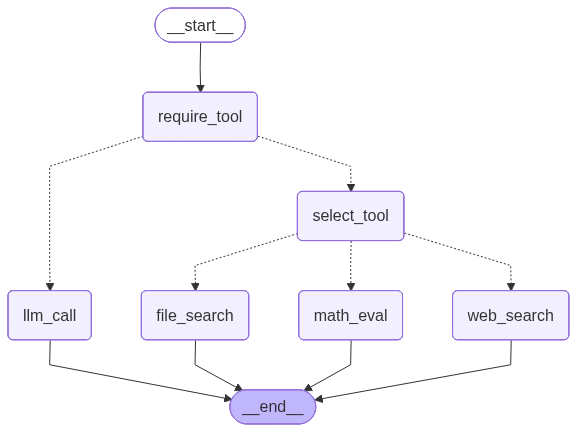

In [12]:
workflow = graph.compile()
workflow

### Execution

##### Web Search


In [13]:
final_state_search = workflow.invoke({"query": "what is elon musk's current networth?"})
console.print_json(data=final_state_search)

{
  "query": "what is elon musk's current networth?",
  "tool_required": "yes",
  "tool_selected": "web_search",
  "tool_params": {
    "search_query": "Elon Musk current net worth"
  },
  "response": "Elon Musk Net Worth Tracker A live, real-time estimate rebuilt from his actual SEC filings as Tesla and SpaceX trade, cross-checked against Forbes and Bloomberg. Every line sourced. Roughly $1.15 trillion as of June 21, 2026. Elon Musk is #1 on Forbes' 2026 Billionaires list. Read more about Elon Musk, their experience, their asset summary, and more here. In May 2026, following the release of the company's prospectus, a $45 billion liability associated Musk's SpaceX stake was removed, leading to a corresponding increase in the net worth calculation. Elon Musk's Net Worth Musk ended 2025 as the world's richest person, with a net worth of $619 billion. The billionaire gained $187 billion on the year and was the first person to ever be worth ... Elon Musk net worth: Elon Musk's net worth ha

#### File Search

In [14]:
final_state_file = workflow.invoke({"query": "read loan_application_status.csv"})
console.print_json(data=final_state_file)


{
  "query": "read loan_application_status.csv",
  "tool_required": "yes",
  "tool_selected": "file_search",
  "tool_params": {
    "filename": "loan_application_status.csv"
  },
  "response": ",name,age,employment_years,monthly_income,credit_score,loan_amount,eligibility_status,credit_score_category,risk_category,approval_status\n0,Rahul Sharma,30,5,100000,800,20000,Eligible,S,Low,Approve\n1,Priya Patel,28,3,100000,680,50000,Eligible,A,Medium,Reject\n2,Amit Verma,35,7,100000,500,10000,Eligible,C,Low,Reject\n3,Rohan Singh,19,1,50000,850,10000,Not Eligible,NA,NA,Reject\n4,Neha Gupta,32,4,50000,780,100000,Eligible,S,High,Reject\n5,Karan Mehta,26,2,70000,720,25000,Eligible,A,Medium,Reject\n6,Sneha Joshi,29,6,120000,790,30000,Eligible,S,Low,Approve\n7,Vikas Rao,40,10,150000,640,60000,Eligible,B,Medium,Reject\n8,Anjali Kulkarni,24,2,60000,560,15000,Eligible,B,Low,Reject\n9,Manoj Desai,45,15,200000,810,50000,Eligible,S,Low,Approve\n10,Pooja Nair,27,3,80000,690,35000,Eligible,A,Medium,Reject\

##### Maths Expression

In [15]:
final_state_math = workflow.invoke({"query": "what is 2 ** 9 / (3 ** 4)"})
console.print_json(data=final_state_math)


{
  "query": "what is 2 ** 9 / (3 ** 4)",
  "tool_required": "yes",
  "tool_selected": "math_eval",
  "tool_params": {
    "expression": "2 ** 9 / (3 ** 4)"
  },
  "response": 6.320987654320987
}


##### LLM call

In [16]:
final_state_llm = workflow.invoke({"query": "what is perplexity metric?"})
console.print_json(data={k: v for k, v in final_state_llm.items() if k != "response"})
console.print(Markdown(final_state_llm["response"]))

{
  "query": "what is perplexity metric?",
  "tool_required": "no"
}
Perplexity is a widely used intrinsic evaluation metric in natural language     
processing (NLP), particularly for assessing the quality of language models     
(LMs).                                                                          

In simple terms, perplexity measures how well a probability model predicts a    
sample of unseen data. For a language model, this means how "surprised" the     
model is by a given piece of text (its test set).                               

Here's a breakdown:                                                             

 1 What it measures:                                                            
    • It quantifies the uncertainty or randomness a language model has when     
      predicting the next word in a sequence, given the preceding words.        
    • A lower perplexity score indicates a better model, as it means the model  
      is less "perplexed" (more confi